# Hyperparameter search with Optuna

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/TXSTCODEPLAYGROUND/CodeCS4337Fall2026/blob/main/LitWBHSTrainingBasicNeuralNetwork/hyperparameter_search.ipynb)

This notebook searches the hyperparameters of the fully connected network of `LitWBHSTrainingBasicNeuralNetwork` with [Optuna](https://optuna.org), then trains the best settings found. Every trial is logged to Weights & Biases (W&B).

### Choose your route

| Route | Sections to run | Search and train with |
| --- | --- | --- |
| **Colab, from notebook cells** | 1 (setup), then 2 to 5 | The cells of sections 3 and 5 |
| **Colab, from Colab's terminal** (Colab Pro) | 1 (setup) in the notebook first; 2, 4, and 5 to read and use the results | The terminal commands in sections 3 and 5; the reload cell then loads the study into the notebook |
| **Locally, from this notebook** | Skip 1, start at [**2. The search space**](#2.-The-search-space) | The cells of sections 3 and 5, with the `.venv` as the notebook's kernel |
| **Locally, from your terminal** | None, no notebook needed (optionally 2, 4, and 5 for the plots) | `python -m LitWBHSTrainingBasicNeuralNetwork.search --config search01.json`, then `python -m LitWBHSTrainingBasicNeuralNetwork --config search01_best.json`, from the repo root with the `.venv` activated |

In Colab, the setup cells are needed even when you search in the terminal: Google Drive can only be mounted, and Colab Secrets only read, from a notebook cell. Locally, set up the repo once first (`.venv`, requirements, and `.env`, see the main README), and open this notebook from the project folder.

In Colab, run the cells from top to bottom:

1. **Set up** the runtime (Colab only): GPU, Google Drive, the repo, and your W&B key.
2. **Look at the search space**: what is searched, and in which ranges.
3. **Run the search**: Optuna trains many settings and keeps the best one.
4. **Read the results**: the best trial, Optuna's plots, and the W&B dashboard.
5. **Train the best config** and test it.

## 1. Setup (Colab)

> **Running locally?** Skip this section: these cells only work in Colab. Jump to [**2. The search space**](#2.-The-search-space).

The same setup as in the starter notebook. First choose a GPU: *Runtime → Change runtime type → GPU*. Then run these cells once per session (and again after the runtime resets): mount Drive, set up the repo, change directory, and load API keys.

Results, including the Optuna study, go to Google Drive, so a search interrupted by a disconnect can be continued (see the tips at the end).

In [ ]:
from google.colab import drive

drive.mount("/content/drive")

In [ ]:
%%bash
set -e

cd /content
if [ -d CodeCS4337Fall2026/.git ]; then
  git -C CodeCS4337Fall2026 pull --ff-only
else
  git clone https://github.com/TXSTCODEPLAYGROUND/CodeCS4337Fall2026.git
fi
cd CodeCS4337Fall2026

# Colab settings: data on the local disk, results in Google Drive.
cp .envcolab .env

# Install only packages Colab does not already have (versions are not pinned).
grep -vE '^\s*(#|$)' requirements.txt \
  | sed -E 's/[<>=!~;[ ].*//' \
  | while read -r pkg; do
      if pip show "$pkg" > /dev/null 2>&1; then
        echo "skip $pkg (already installed)"
      else
        pip install -q "$pkg" && echo "installed $pkg"
      fi
    done

In [ ]:
# The bash cell above cannot change the notebook's working directory, so do it here.
%cd /content/CodeCS4337Fall2026

### Load your W&B key (optional)

Add your key as a Colab **Secret** named `WANDB_API_KEY` (key icon in the left sidebar → *Add new secret*). Never type it into a cell. The cell below loads `.env`, then looks up missing keys in your Secrets, adds them to this notebook's environment, and saves them to `.env` so terminal runs find them too. Without a key, every trial is logged to W&B offline and can be uploaded later with `wandb sync`.

In [ ]:
import os
from pathlib import Path

from dotenv import load_dotenv
from google.colab import userdata

ENV_FILE = Path("/content/CodeCS4337Fall2026/.env")
KEYS = ["WANDB_API_KEY"]

if load_dotenv(ENV_FILE):
    print(f"Loaded settings from {ENV_FILE}")
else:
    print(f"No settings in {ENV_FILE}: run the setup cells first")

for key in KEYS:
    if os.getenv(key):
        print(f"{key}: found in .env")
        continue
    try:
        os.environ[key] = userdata.get(key)
    except Exception:  # noqa: BLE001 (Secret not added or access not granted)
        print(f"{key}: not found, W&B will log offline")
        continue
    with ENV_FILE.open("a") as env_file:
        env_file.write(f"\n{key}={os.environ[key]}\n")
    print(f"{key}: loaded from Colab Secrets and saved to .env")

## 2. The search space

This cell makes the project importable (in Colab and locally) and imports its two entry points: `search` runs the Optuna study, `main` trains and tests one config.

In [1]:
import sys
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
REPO = Path("/content/CodeCS4337Fall2026") if IN_COLAB else Path.cwd().parent
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

from LitWBHSTrainingBasicNeuralNetwork import main
from LitWBHSTrainingBasicNeuralNetwork.search import search
from LitWBHSTrainingBasicNeuralNetwork.utils import CONFIGS_DIR

print((CONFIGS_DIR / "search01.json").read_text())

{
  "base_config": "config01.json",
  "study": {
    "n_trials": 30,
    "timeout_minutes": null,
    "seed": 42,
    "train_fraction": 1.0,
    "pruner_startup_trials": 5,
    "pruner_warmup_epochs": 2,
    "log_trials_to_wandb": true
  },
  "search_space": {
    "n_layers": [1, 3],
    "units": [64, 128, 256, 512],
    "activation": ["relu", "leaky_relu", "gelu", "tanh"],
    "dropout": [0.0, 0.5],
    "batch_size": [64, 128, 256],
    "epochs": [5, 15],
    "optimizer": ["adam", "adamw", "sgd", "rmsprop"],
    "lr": [0.0001, 0.1],
    "momentum": [0.5, 0.99],
    "regularization": ["none", "l1", "l2", "l1_l2"],
    "l1": [1e-7, 1e-4],
    "l2": [1e-6, 1e-2],
    "scheduler": ["none", "step", "cosine", "plateau"],
    "step_size": [2, 5],
    "gamma": [0.1, 0.7],
    "early_stopping": [true, false],
    "patience": [2, 5]
  }
}



/home/virgo/Desktop/projects/CodeCS4337Fall2026/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


The search config has three parts:

- `base_config`: the training config every trial starts from. Everything not searched (seed, validation split, W&B project) comes from it.
- `study`: how many trials to run (`n_trials`), an optional time limit (`timeout_minutes`), the sampler's seed, the fraction of the training data each trial uses (`train_fraction`), the pruner settings, and whether trials are logged to W&B.
- `search_space`: a range `[low, high]` or a list of choices for every hyperparameter.

| Hyperparameter | What it controls |
| --- | --- |
| `n_layers`, `units` | Number of hidden layers, and the units of each one (picked per layer) |
| `activation` | ReLU, Leaky ReLU, GELU, or tanh after every hidden layer |
| `dropout` | Dropout probability after every hidden layer |
| `batch_size` | Samples per training step |
| `epochs` | Maximum number of epochs |
| `optimizer`, `lr`, `momentum` | Adam, AdamW, SGD, or RMSprop; the learning rate (searched on a log scale); momentum (SGD and RMSprop only) |
| `regularization`, `l1`, `l2` | No penalty, L1 (pushes weights to zero), L2 (weight decay, shrinks weights), or both, with their weights (log scale) |
| `scheduler`, `step_size`, `gamma` | Constant learning rate, step decay, cosine decay, or reduce-on-plateau, with their settings |
| `early_stopping`, `patience` | Whether to stop when validation accuracy stops improving, and after how many epochs |

Some hyperparameters only exist for some choices, e.g. `momentum` only for SGD and RMSprop. Optuna handles this naturally: the search space is defined by running Python code (`suggest_config` in `search.py`), so an `if` decides what is sampled.

**To change the search**, copy `search01.json` in the file browser (left sidebar, `CodeCS4337Fall2026/LitWBHSTrainingBasicNeuralNetwork/configs/`), e.g. to `search02.json`, edit it, and pass its name below. To fix a hyperparameter instead of searching it, give a single choice (`["adam"]`) or a range with equal ends (`[10, 10]`). Fewer searched hyperparameters means fewer trials are needed.

## 3. Run the search

Each trial trains one setting on the training split and is scored by its best **validation** accuracy. The test set is never used during the search: choosing settings by their test score would make that score optimistic.

- Optuna's **TPE sampler** picks each trial's settings from how earlier trials did: after the first random trials, it samples more where the scores were good.
- The **median pruner** stops a trial early when its validation accuracy after an epoch is below the median of earlier trials at the same epoch. Pruned trials save time for promising ones.

A trial takes from a few seconds to a minute or more on a GPU, so 30 trials take roughly 10 to 30 minutes. Try `N_TRIALS = 3` first to check that everything works. Running the cell again **adds** trials to the same study instead of starting over.

**Faster trials with less data:** `TRAIN_FRACTION` is the fraction of the 54,000 training images each trial trains on. In Colab, which has only 2 CPU cores to load images, `0.25` makes every epoch about 4 times faster. The validation set stays complete, so the scores remain reliable, and the best config is still trained on all the data in section 5. The trade-off: settings that depend on the amount of data (epochs, dropout, L1/L2 strength) may not transfer exactly, so prefer `1.0` when you have the time. Keep the same fraction for all trials of a study; to change it, use a new search config name.

In [2]:
SEARCH_CONFIG = "search01.json"
N_TRIALS = 50
TRAIN_FRACTION = 0.10  # e.g. 0.25 in Colab for faster trials

study = search(SEARCH_CONFIG, n_trials=N_TRIALS, train_fraction=TRAIN_FRACTION)

[I 2026-10-02 19:13:47,136] A new study created in RDB with name: search01


Trials train on 10% of the training split.


wandb: WARNING The anonymous setting has no effect and will be removed in a future version.
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.


/home/virgo/Desktop/projects/CodeCS4337Fall2026/.venv/lib/python3.13/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/home/virgo/Desktop/projects/CodeCS4337Fall2026/.venv/lib/python3.13/site-packages/lightning/pytorch/loops/fit_loop.py:321: The number of training batches (22) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


[I 2026-10-02 19:13:55,221] Trial 0 finished with value: 0.4273333251476288 and parameters: {'n_layers': 2, 'units_layer1': 64, 'units_layer2': 256, 'activation': 'gelu', 'dropout': 0.10616955533913808, 'batch_size': 256, 'epochs': 10, 'optimizer': 'sgd', 'lr': 0.0007523742884534858, 'momentum': 0.6795173032139089, 'regularization': 'l1', 'l1': 5.987474910461399e-06, 'scheduler': 'step', 'step_size': 5, 'gamma': 0.6793792198447356, 'early_stopping': True, 'patience': 2}. Best is trial 0 with value: 0.4273333251476288.


...

/home/virgo/Desktop/projects/CodeCS4337Fall2026/.venv/lib/python3.13/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/home/virgo/Desktop/projects/CodeCS4337Fall2026/.venv/lib/python3.13/site-packages/lightning/pytorch/loops/fit_loop.py:321: The number of training batches (43) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


[I 2026-10-02 19:22:29,372] Trial 48 pruned. val_acc=0.5418 at epoch 2


/home/virgo/Desktop/projects/CodeCS4337Fall2026/.venv/lib/python3.13/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/home/virgo/Desktop/projects/CodeCS4337Fall2026/.venv/lib/python3.13/site-packages/lightning/pytorch/loops/fit_loop.py:321: The number of training batches (43) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


[I 2026-10-02 19:22:40,785] Trial 49 finished with value: 0.8578333258628845 and parameters: {'n_layers': 2, 'units_layer1': 256, 'units_layer2': 512, 'activation': 'relu', 'dropout': 0.08070195410347653, 'batch_size': 128, 'epochs': 14, 'optimizer': 'adam', 'lr': 0.0007608365977273186, 'regularization': 'l1_l2', 'l1': 2.0699723878174058e-07, 'l2': 5.429691010141346e-05, 'scheduler': 'cosine', 'early_stopping': False}. Best is trial 34 with value: 0.8658333420753479.



Study 'search01': 50 trials, 34 complete, 16 pruned. Results in /home/virgo/Desktop/projects/CodeCS4337Fall2026/runs/LitWBHSTrainingBasicNeuralNetwork/search01
Best trial: 34, val_acc 0.8658
  n_layers: 2
  units_layer1: 256
  units_layer2: 512
  activation: relu
  dropout: 0.06430665346193094
  batch_size: 128
  epochs: 13
  optimizer: adam
  lr: 0.0020421694493485965
  regularization: l1_l2
  l1: 1.1686048048779343e-07
  l2: 8.225344533366124e-06
  scheduler: cosine
  early_stopping: False
Saved its config as configs/search01_best.json. Train and test it with:
  python -m LitWBHSTrainingBasicNeuralNetwork --config search01_best.json


**Or from a terminal** (the same search; the notebook stays free while it runs in Colab's terminal):

```bash
cd /content/CodeCS4337Fall2026
python -m LitWBHSTrainingBasicNeuralNetwork.search --config search01.json --n-trials 30 --train-fraction 1.0
```

Then load the study in the notebook with the next cell (`N_TRIALS = 0` runs no new trial).

In [3]:
# Reload a saved study (after a terminal search or a runtime reset) without new trials.
study = search(SEARCH_CONFIG, n_trials=0)

[I 2026-10-02 19:23:09,759] Using an existing study with `study_name='search01'` instead of creating a new one.



Study 'search01': 50 trials, 34 complete, 16 pruned. Results in /home/virgo/Desktop/projects/CodeCS4337Fall2026/runs/LitWBHSTrainingBasicNeuralNetwork/search01
Best trial: 34, val_acc 0.8658
  n_layers: 2
  units_layer1: 256
  units_layer2: 512
  activation: relu
  dropout: 0.06430665346193094
  batch_size: 128
  epochs: 13
  optimizer: adam
  lr: 0.0020421694493485965
  regularization: l1_l2
  l1: 1.1686048048779343e-07
  l2: 8.225344533366124e-06
  scheduler: cosine
  early_stopping: False
Saved its config as configs/search01_best.json. Train and test it with:
  python -m LitWBHSTrainingBasicNeuralNetwork --config search01_best.json


## 4. Read the results

The ten best trials, best first:

In [4]:
from optuna.trial import TrialState

complete = study.get_trials(states=[TrialState.COMPLETE])
pruned = study.get_trials(states=[TrialState.PRUNED])
print(f"{len(complete)} complete, {len(pruned)} pruned\n")
for trial in sorted(complete, key=lambda t: t.value, reverse=True)[:10]:
    print(f"trial {trial.number:3d}  val_acc {trial.value:.4f}  {trial.params}\n")

34 complete, 16 pruned

trial  34  val_acc 0.8658  {'n_layers': 2, 'units_layer1': 256, 'units_layer2': 512, 'activation': 'relu', 'dropout': 0.06430665346193094, 'batch_size': 128, 'epochs': 13, 'optimizer': 'adam', 'lr': 0.0020421694493485965, 'regularization': 'l1_l2', 'l1': 1.1686048048779343e-07, 'l2': 8.225344533366124e-06, 'scheduler': 'cosine', 'early_stopping': False}

trial  46  val_acc 0.8632  {'n_layers': 2, 'units_layer1': 256, 'units_layer2': 512, 'activation': 'relu', 'dropout': 0.05677374872007203, 'batch_size': 128, 'epochs': 9, 'optimizer': 'adamw', 'lr': 0.002374402640031866, 'regularization': 'none', 'scheduler': 'cosine', 'early_stopping': False}

trial  25  val_acc 0.8623  {'n_layers': 2, 'units_layer1': 256, 'units_layer2': 512, 'activation': 'relu', 'dropout': 0.14723474441723178, 'batch_size': 128, 'epochs': 13, 'optimizer': 'adamw', 'lr': 0.0022688659185577994, 'regularization': 'l1_l2', 'l1': 7.676652306908994e-07, 'l2': 4.96679757508791e-06, 'scheduler': 'co

### Optuna's plots

- **Optimization history:** each trial's score, and the best so far. It should rise quickly, then flatten: more trials then bring little.
- **Intermediate values:** the validation accuracy of every trial, epoch by epoch. Pruned trials are the short lines that stop early.
- **Hyperparameter importances:** how much of the variation in score each hyperparameter explains. Important ones deserve a finer search; unimportant ones can be fixed.
- **Slice plot:** the score against the value of one hyperparameter, one dot per trial. Where are the good learning rates?

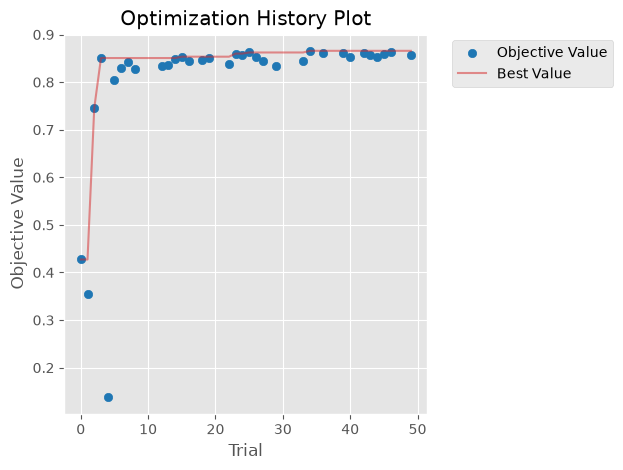

/home/virgo/Desktop/projects/CodeCS4337Fall2026/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:158: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.canvas.print_figure(bytes_io, **kw)


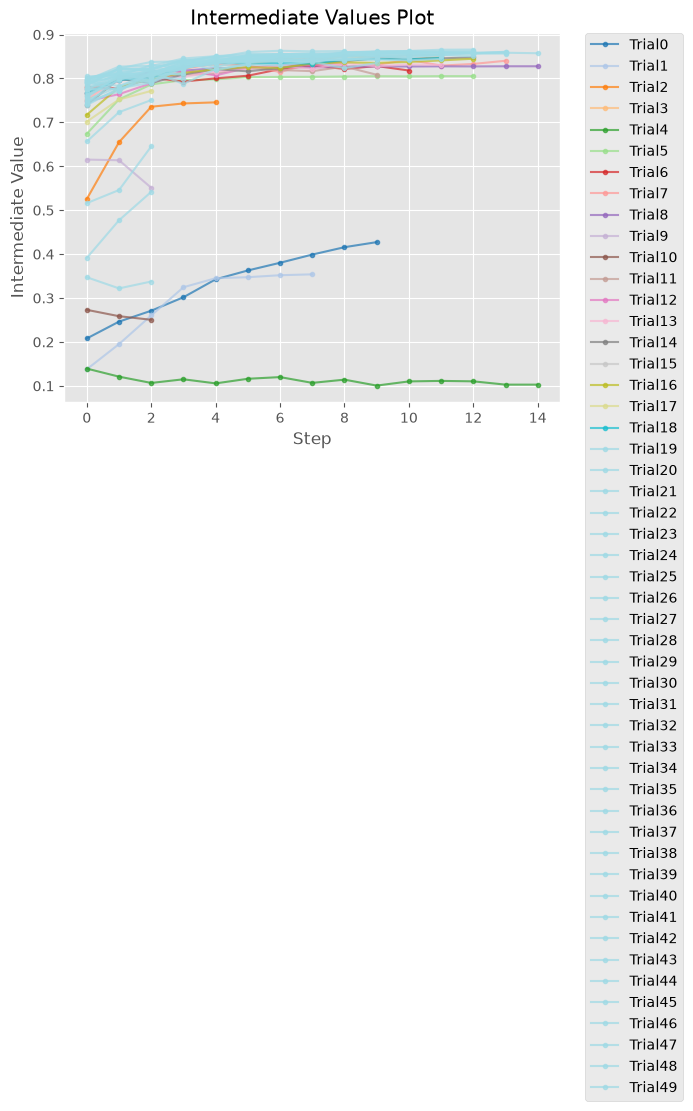

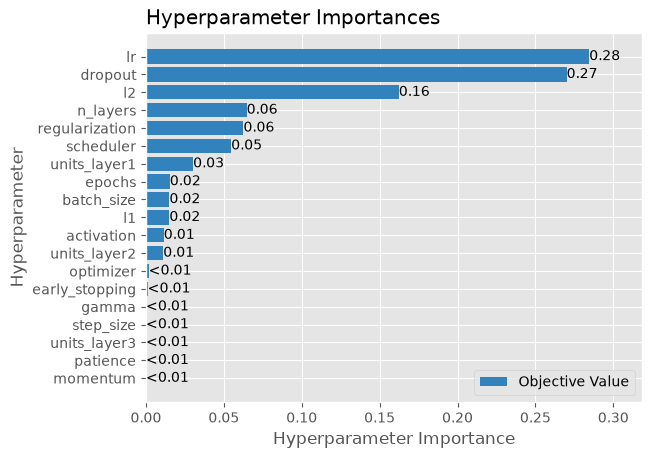

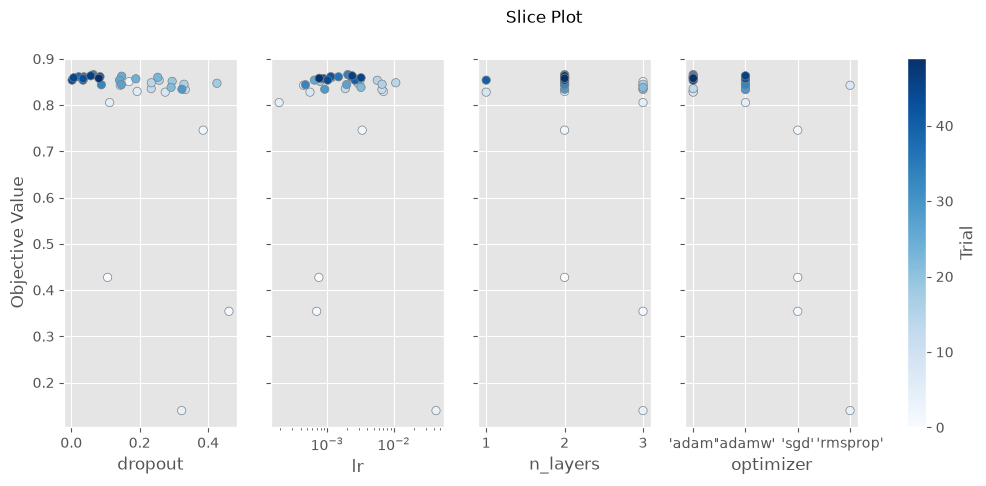

In [5]:
import warnings

import matplotlib.pyplot as plt
import optuna
from optuna.visualization import matplotlib as optuna_plots

# Optuna's matplotlib plots are marked experimental; the warning is not useful here.
warnings.filterwarnings("ignore", category=optuna.exceptions.ExperimentalWarning)

optuna_plots.plot_optimization_history(study)
plt.show()
optuna_plots.plot_intermediate_values(study)
plt.show()
optuna_plots.plot_param_importances(study)
plt.show()
optuna_plots.plot_slice(study, params=["lr", "dropout", "optimizer", "n_layers"])
plt.show()

100%|██████████| 50/50 [00:09<00:00,  5.23it/s]


<Axes: title={'center': 'Terminator Improvement Plot'}, xlabel='Trial', ylabel='Terminator Improvement'>

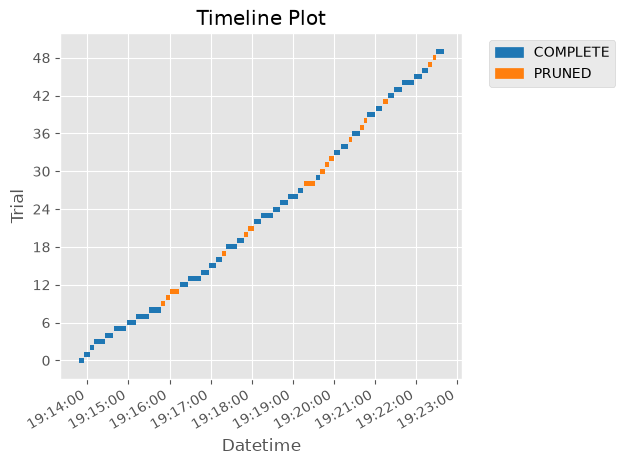

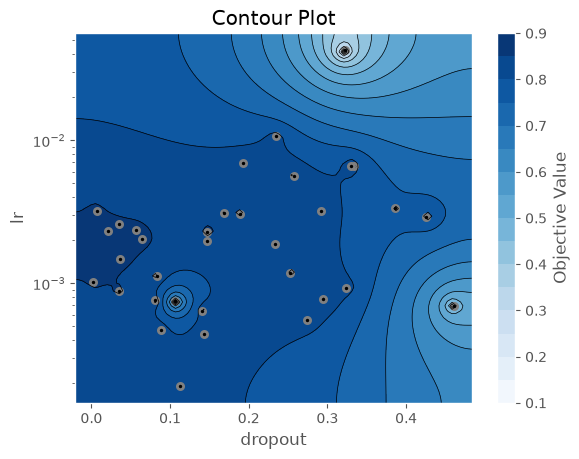

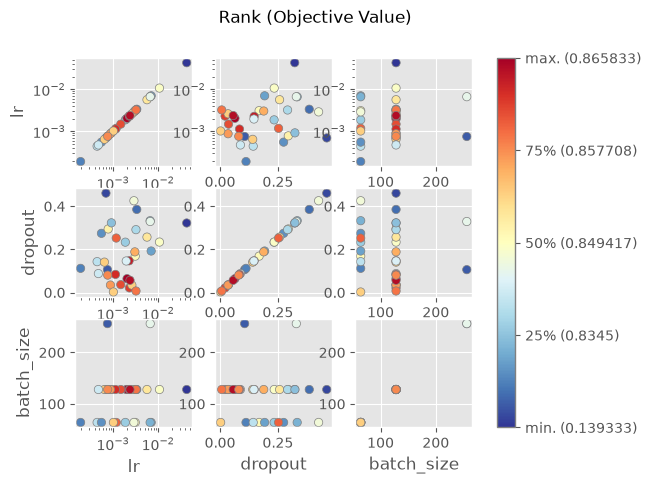

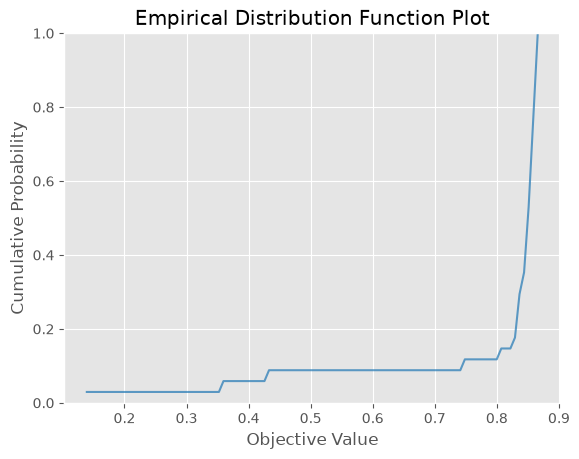

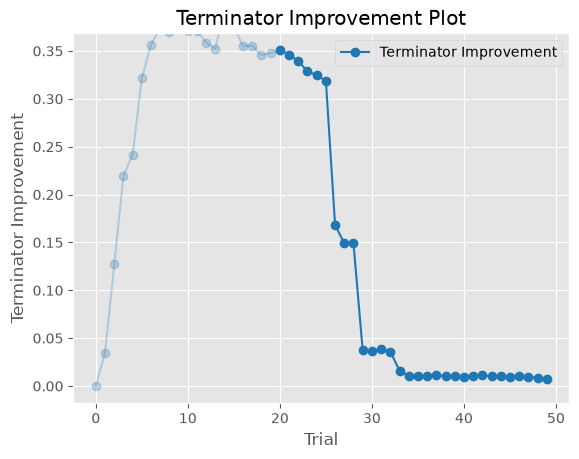

In [10]:
optuna_plots.plot_timeline(study)
optuna_plots.plot_contour(study, params=["lr", "dropout"])
optuna_plots.plot_rank(study, params=["lr", "dropout", "batch_size"])
optuna_plots.plot_edf(study)
optuna_plots.plot_terminator_improvement(study)

### The W&B dashboard

Every trial is a W&B run in the project `LitWBHSTrainingBasicNeuralNetwork`, grouped under the search's name (`search01`), with its settings in the run config and `best_val_acc` and `state` (`complete` or `pruned`) in the summary. On wandb.ai:

1. In the **Runs** table, group by `group`, show the columns you care about (`training.optimizer`, `training.lr`, `best_val_acc`, ...), and sort by `best_val_acc`.
2. Add a **Parallel coordinates** panel with the searched settings and `best_val_acc`: one line per trial, so you can follow the best lines back to their settings.
3. Add a **Parameter importance** panel for `best_val_acc`: W&B's own estimate of which settings matter.
4. The `val_acc` and `lr-...` charts overlay all trials, showing what the schedulers and early stopping did.

Without a key, upload the trials later with the `wandb sync` command printed during the search.

## 5. Train the best config

The search saved the best trial's settings as a normal training config, `configs/search01_best.json` (and a copy, `best_config.json`, next to the study in Drive). Its `found_by` entry records which trial it came from.

In [ ]:
best_config_name = f"{Path(SEARCH_CONFIG).stem}_best.json"
print((CONFIGS_DIR / best_config_name).read_text())

Train it like any other config: a full run with checkpoints, then **one** evaluation on the test set, which is the score to report. The run is logged to W&B in the group `search01_best`, next to the trials. The same from a terminal: `python -m LitWBHSTrainingBasicNeuralNetwork --config search01_best.json`.

In [ ]:
best_metrics = main(best_config_name)
print(f"Test accuracy of the best config: {best_metrics['test_acc']:.4f}")

**Compare with the starting point** (optional): `config01.json` holds the default settings (Adam, learning rate 0.001, two hidden layers of 256 and 128 units, 10 epochs). Did the search beat it on the test set?

In [ ]:
baseline_metrics = main("config01.json")
print(
    f"Baseline {baseline_metrics['test_acc']:.4f}, best config {best_metrics['test_acc']:.4f}"
)

## Tips

**Long searches in Colab**
- The study is saved in Google Drive (`MyDrive/CodeCS4337Fall2026/runs/LitWBHSTrainingBasicNeuralNetwork/search01/study.db`) after every trial. After a disconnect, re-run the setup cells and the search cell: the finished trials are kept and new ones are added.
- `configs/search01_best.json` is in `/content`, which is deleted when the runtime resets. Get it back with the reload cell (`n_trials=0`), which rewrites it from the study.
- Set `timeout_minutes` in the search config to stop starting new trials after a time limit.
- The tips at the end of the starter notebook (idle disconnects, GPU quota) apply here too.

**Searching well**
- Start wide, then narrow: after a first search, read the importances and slice plots, fix the unimportant hyperparameters, and search the important ones in a smaller range (`search02.json`).
- To start a search over, use a new search config name, or delete its folder in Drive.
- Fewer epochs per trial make the search faster, but favor settings that learn fast rather than settings that end best.